# GeoClip Italy -- Fine-Tuning (ItalyDataset)

Fine-tunes GeoCLIP on the pre-filtered Italy dataset produced by `Italy_Dataset_Builder.ipynb`.
Images are loaded from three compact region TAR archives (Nord / Centro / Sud_Isole) on Drive
and extracted to Colab local disk on demand.

## Run Guide

| # | Section | When to run |
|---|---------|-------------|
| 1 | Setup | Every session |
| 2 | Dataset | Every session (safe to re-run; already-extracted images are skipped) |
| 3 | Model & Optimizer | Every session |
| 4 | Training | Main loop -- resumable |
| 5 | Evaluation | After training |

**Resume training**: set `LOAD_CHECKPOINT = True` and point `CHECKPOINT_PATH` to the latest checkpoint.  
**New images added to dataset**: re-run `Italy_Dataset_Builder.ipynb` first, then re-run Sections 2 and 3 here.

## Section 1 -- Setup

Run cells 2-4 at the start of every session.

In [1]:
# Install -- run every session
%pip install -q geoclip pandas torch torchvision tqdm scikit-learn peft
%pip install -q folium seaborn matplotlib Pillow geopy
%pip uninstall -y -q torchao
print("Packages ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 MB 23.5 MB/s eta 0:00:00
Packages ready.


In [2]:
import os

# ============================================================
# GLOBAL CONFIGURATION -- edit only this cell
# ============================================================

# Google Drive paths
DRIVE_BASE = "/content/drive/MyDrive/Vision_Project_2026"

# Input: master CSV and region TAR archives from Italy_Dataset_Builder.ipynb
DRIVE_MASTER_CSV     = f"{DRIVE_BASE}/ItalyDataset/italy_master.csv"
DRIVE_ITALY_TARS_DIR = f"{DRIVE_BASE}/ItalyDataset/archives"

DRIVE_CHECKPOINT_DIR = f"{DRIVE_BASE}/checkpoints_v2"
os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)

LOCAL_EXTRACT_DIR = "/content/gld_images"
os.makedirs(LOCAL_EXTRACT_DIR, exist_ok=True)

# -- Region filter --
# List of regions to include in training. Set to None to use all three.
# Options: 'nord', 'centro', 'sud_isole'
TRAIN_REGIONS = None  # e.g. ['nord', 'centro'] to exclude Sud/Isole

# -- Italy bounding box (must match Italy_Dataset_Builder.ipynb) --
MIN_LAT, MAX_LAT = 35.4, 47.2
MIN_LON, MAX_LON =  6.6, 18.8

# -- Data split --
TEST_SIZE   = 0.15
VAL_SIZE    = 0.15
RANDOM_SEED = 42

# -- Training hyperparameters --
BATCH_SIZE           = 16
LEARNING_RATE        = 1e-4
WEIGHT_DECAY         = 1e-4
TOTAL_EPOCHS         = 30
CHECKPOINT_FREQUENCY = 1
USE_AMP              = True
GRAD_CLIP            = 1.0

# -- Resume --
LOAD_CHECKPOINT = True
CHECKPOINT_PATH = None
BEST_MODEL_PATH = f"{DRIVE_CHECKPOINT_DIR}/geoclip_italy_BEST.pth"

print("Config loaded.")
print(f"  Master CSV     : {DRIVE_MASTER_CSV}")
print(f"  Italy TARs dir : {DRIVE_ITALY_TARS_DIR}")
print(f"  Checkpoint dir : {DRIVE_CHECKPOINT_DIR}")
print(f"  Train regions  : {TRAIN_REGIONS if TRAIN_REGIONS is not None else 'all'}")
print(f"  Resume         : {LOAD_CHECKPOINT}")

Config loaded.
  Master CSV     : /content/drive/MyDrive/Vision_Project_2026/ItalyDataset/italy_master.csv
  Italy TARs dir : /content/drive/MyDrive/Vision_Project_2026/ItalyDataset/archives
  Checkpoint dir : /content/drive/MyDrive/Vision_Project_2026/checkpoints_v6
  Train regions  : all
  Resume         : True


In [3]:
from google.colab import drive
import os
import shutil

# Check if drive is already mounted
if os.path.exists('/content/drive') and os.path.ismount('/content/drive'):
    print("Drive is already mounted. Unmounting...")
    drive.flush_and_unmount()

# If /content/drive exists and contains files (meaning it's not mounted
# but contains previous data that might cause issues with force_remount=True),
# remove its contents.
if os.path.exists('/content/drive') and os.listdir('/content/drive'):
    print("Mountpoint contains files but is not mounted. Removing directory contents...")
    for item in os.listdir('/content/drive'):
        item_path = os.path.join('/content/drive', item)
        try:
            if os.path.isfile(item_path) or os.path.islink(item_path):
                os.unlink(item_path)
            elif os.path.isdir(item_path):
                shutil.rmtree(item_path)
        except Exception as e:
            print(f"Error removing {item_path}: {e}")

print("Mounting Google Drive...")
drive.mount('/content/drive', force_remount=True)

Mountpoint contains files but is not mounted. Removing directory contents...
Mounting Google Drive...
Mounted at /content/drive


## Section 2 -- Dataset

Loads `italy_master.csv` (produced by `Italy_Dataset_Builder.ipynb`), extracts the three
region TAR archives to Colab local disk, and builds a fast `image_id → local_path` index.

**Already-extracted regions are skipped** -- safe to re-run each session.  
**New images**: re-run `Italy_Dataset_Builder.ipynb` to rebuild the TARs, then re-run this section.

In [4]:
import pandas as pd

print(f"Loading: {DRIVE_MASTER_CSV}")
raw_df = pd.read_csv(DRIVE_MASTER_CSV)
print(f"  Raw rows : {len(raw_df):,}")
print(f"  Columns  : {list(raw_df.columns)}")

# master CSV is already filtered and clean; just normalise types
raw_df['image_id'] = raw_df['image_id'].astype(str)
raw_df['lat']      = pd.to_numeric(raw_df['lat'], errors='coerce')
raw_df['lon']      = pd.to_numeric(raw_df['lon'], errors='coerce')

italy_df = raw_df.dropna(subset=['image_id', 'lat', 'lon', 'local_path']).copy()

# Optional region filter
if TRAIN_REGIONS is not None:
    before   = len(italy_df)
    italy_df = italy_df[italy_df['region'].isin(TRAIN_REGIONS)].reset_index(drop=True)
    print(f"  Region filter {TRAIN_REGIONS}: {before:,} -> {len(italy_df):,} rows")
else:
    italy_df = italy_df.reset_index(drop=True)

print(f"\nReady rows : {len(italy_df):,}")
print(f"Lat range  : [{italy_df['lat'].min():.3f}, {italy_df['lat'].max():.3f}]")
print(f"Lon range  : [{italy_df['lon'].min():.3f}, {italy_df['lon'].max():.3f}]")
print(f"Regions    : {italy_df['region'].value_counts().to_dict()}")

Loading: /content/drive/MyDrive/Vision_Project_2026/ItalyDataset/italy_master.csv
  Raw rows : 65,278
  Columns  : ['image_id', 'local_path', 'lat', 'lon', 'region', 'shard', 'wiki_url', 'landmark_id', 'license', 'author', 'supercategory', 'natural_or_human_made', 'dataset']

Ready rows : 65,278
Lat range  : [36.686, 47.060]
Lon range  : [6.752, 18.450]
Regions    : {'nord': 31573, 'centro': 23170, 'sud_isole': 10535}


In [5]:
import os
import tarfile
from tqdm import tqdm

ALL_REGIONS = ['nord', 'centro', 'sud_isole']


def find_region_tar(region):
    """Return the Drive path to a region TAR, or None if it doesn't exist."""
    p = os.path.join(DRIVE_ITALY_TARS_DIR, f'italy_{region}.tar')
    return p if os.path.exists(p) else None


def region_sample_exists(region):
    """Return True if at least one image from this region is already on local disk."""
    subset = italy_df[italy_df['region'] == region].head(3)
    for img_id in subset['image_id']:
        if os.path.exists(os.path.join(LOCAL_EXTRACT_DIR, f'{img_id}.jpg')):
            return True
    return False


def extract_region_tar(tar_path):
    """Extract a flat region TAR (all files are {image_id}.jpg at root level)."""
    size_mb = os.path.getsize(tar_path) / (1024 * 1024)
    print(f"  Extracting {os.path.basename(tar_path)} ({size_mb:.0f} MB) ...")
    with tarfile.open(tar_path, 'r') as tar:
        try:
            tar.extractall(path=LOCAL_EXTRACT_DIR, filter='data')
        except TypeError:
            tar.extractall(path=LOCAL_EXTRACT_DIR)

In [6]:
regions_needed = italy_df['region'].dropna().unique().tolist()
print(f"Regions in dataset: {regions_needed}")

already_done, to_extract, no_tar = [], [], []

for region in regions_needed:
    if region_sample_exists(region):
        already_done.append(region)
    elif find_region_tar(region) is not None:
        to_extract.append(region)
    else:
        no_tar.append(region)

print(f"  Already extracted : {already_done}")
print(f"  Will extract now  : {to_extract}")
print(f"  TAR not found     : {no_tar} (run Italy_Dataset_Builder.ipynb first)")

for region in tqdm(to_extract, desc='Extracting region TARs'):
    extract_region_tar(find_region_tar(region))

if no_tar:
    print(f"\nWARNING: TARs missing for {no_tar}. Those images will not be available for training.")

print("\nExtraction step complete.")

Regions in dataset: ['nord', 'centro', 'sud_isole']
  Already extracted : []
  Will extract now  : ['nord', 'centro', 'sud_isole']
  TAR not found     : [] (run Italy_Dataset_Builder.ipynb first)


Extracting region TARs:   0%|          | 0/3 [00:00<?, ?it/s]

  Extracting italy_nord.tar (1911 MB) ...


Extracting region TARs:  33%|███▎      | 1/3 [00:39<01:18, 39.49s/it]

  Extracting italy_centro.tar (1413 MB) ...


Extracting region TARs:  67%|██████▋   | 2/3 [01:17<00:38, 38.63s/it]

  Extracting italy_sud_isole.tar (662 MB) ...


Extracting region TARs: 100%|██████████| 3/3 [01:33<00:00, 31.04s/it]


Extraction step complete.


In [7]:
# Build fast image_id -> local path index
# Region TARs store images flat: LOCAL_EXTRACT_DIR/{image_id}.jpg
print("Building image index ...")

image_index = {}
for img_id in italy_df['image_id']:
    path = os.path.join(LOCAL_EXTRACT_DIR, f'{img_id}.jpg')
    if os.path.exists(path):
        image_index[img_id] = path

found   = len(image_index)
missing = len(italy_df) - found
print(f"  Found   : {found:,} images  ({found / max(len(italy_df), 1) * 100:.1f}%)")
print(f"  Missing : {missing:,} (TAR not yet extracted or image absent)")

trainable_df = italy_df[italy_df['image_id'].isin(image_index)].copy()
print(f"\nTrainable rows: {len(trainable_df):,}")
print(f"By region:")
print(trainable_df['region'].value_counts().to_string())

if len(trainable_df) < 100:
    print('WARNING: very few images found. Verify DRIVE_ITALY_TARS_DIR and that region TARs are extracted.')

Building image index ...
  Found   : 32,687 images  (50.1%)
  Missing : 32,591 (TAR not yet extracted or image absent)

Trainable rows: 32,687
By region:
region
nord         15767
centro       11587
sud_isole     5333


## Section 3 -- Model, Loss & Optimizer

Run all cells in order. After re-running Section 2 (new data), re-run this section to rebuild loaders -- checkpoint weights are preserved.

In [8]:
import torch
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms


class GLDv2ItalyDataset(Dataset):
    def __init__(self, df, image_index, transform=None):
        self.df          = df.reset_index(drop=True)
        self.image_index = image_index
        self.transform   = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        image_id = str(row['image_id'])
        lat      = max(MIN_LAT, min(MAX_LAT, float(row['lat'])))
        lon      = max(MIN_LON, min(MAX_LON, float(row['lon'])))

        norm_lat = (lat - MIN_LAT) / (MAX_LAT - MIN_LAT)
        norm_lon = (lon - MIN_LON) / (MAX_LON - MIN_LON)
        target   = torch.tensor([norm_lat, norm_lon], dtype=torch.float32)

        path = self.image_index.get(image_id, '')
        try:
            image = Image.open(path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (224, 224), color=(128, 128, 128))

        if self.transform:
            image = self.transform(image)
        return image, target


train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomRotation(15),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
                         std=[0.26862954, 0.26130258, 0.27577711]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
                         std=[0.26862954, 0.26130258, 0.27577711]),
])

temp_df, test_df = train_test_split(trainable_df, test_size=TEST_SIZE,  random_state=RANDOM_SEED)
train_df, val_df = train_test_split(temp_df,      test_size=VAL_SIZE,   random_state=RANDOM_SEED)

print(f"Split -- train: {len(train_df):,} | val: {len(val_df):,} | test: {len(test_df):,}")

train_loader = DataLoader(GLDv2ItalyDataset(train_df, image_index, train_transform),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=2,
                          pin_memory=True, drop_last=True)
val_loader   = DataLoader(GLDv2ItalyDataset(val_df,   image_index, val_transform),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(GLDv2ItalyDataset(test_df,  image_index, val_transform),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Batches -- train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")

Split -- train: 23,615 | val: 4,168 | test: 4,904
Batches -- train: 1475 | val: 261 | test: 307


In [9]:
# Clear previous model from GPU before re-initialising
import torch

try:
    del model
    print("Previous model removed from GPU.")
except NameError:
    pass

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name} -- {props.total_memory / 1e9:.1f} GB")


GPU: Tesla T4 -- 15.6 GB


In [10]:
import torch.nn as nn
from peft import LoraConfig, TaskType, get_peft_model
from geoclip.model import GeoCLIP


class GeoClipItaly(nn.Module):
    """GeoCLIP backbone with a regression head for Italy GPS prediction.

    Architecture:
    - All base GeoCLIP weights frozen.
    - LoRA (rank=8, alpha=16) on q_proj + v_proj in every vision transformer layer.
    - visual_projection and image_encoder.mlp unfrozen for domain adaptation.
    - Custom regressor head (512 -> 1024 -> 512 -> 256 -> 2) fully trainable.
    """

    def __init__(self, lora_rank=8, lora_alpha=16, lora_dropout=0.05):
        super().__init__()
        self.geoclip = GeoCLIP(from_pretrained=True)

        # 1. Freeze everything first
        for param in self.geoclip.parameters():
            param.requires_grad = False

        # 2. Apply LoRA to Q/V projections in every ViT attention layer
        lora_config = LoraConfig(
            r=lora_rank,
            lora_alpha=lora_alpha,
            target_modules=['q_proj', 'v_proj'],
            lora_dropout=lora_dropout,      # 0.05 helps with 34K-image dataset
            bias='none',
            task_type=TaskType.FEATURE_EXTRACTION,
        )
        self.geoclip.image_encoder.CLIP.vision_model = get_peft_model(
            self.geoclip.image_encoder.CLIP.vision_model,
            lora_config,
        )

        # 3. Unfreeze domain-adaptation layers outside the LoRA scope
        for p in self.geoclip.image_encoder.CLIP.visual_projection.parameters():
            p.requires_grad = True
        for p in self.geoclip.image_encoder.mlp.parameters():
            p.requires_grad = True

        # Keep CLIP backbone in eval (BatchNorm/Dropout stats frozen)
        self.geoclip.eval()

        # 4. Regression head -- always fully trainable
        self.regressor = nn.Sequential(
            nn.Linear(512, 1024), nn.BatchNorm1d(1024), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(1024, 512), nn.BatchNorm1d(512),  nn.GELU(), nn.Dropout(0.2),
            nn.Linear(512,  256), nn.BatchNorm1d(256),  nn.GELU(), nn.Dropout(0.1),
            nn.Linear(256,    2), nn.Sigmoid(),
        )

        # Param summary by component
        def count(mod): return sum(p.numel() for p in mod.parameters() if p.requires_grad)
        lora_p   = count(self.geoclip.image_encoder.CLIP.vision_model)
        proj_p   = count(self.geoclip.image_encoder.CLIP.visual_projection)
        mlp_p    = count(self.geoclip.image_encoder.mlp)
        reg_p    = count(self.regressor)
        total    = sum(p.numel() for p in self.parameters())
        trainable = lora_p + proj_p + mlp_p + reg_p
        print(f"Trainable: {trainable:,} / {total:,}  ({trainable/total*100:.2f}%)")
        print(f"  LoRA adapters     : {lora_p:>10,}")
        print(f"  visual_projection : {proj_p:>10,}")
        print(f"  image_encoder.mlp : {mlp_p:>10,}")
        print(f"  regressor head    : {reg_p:>10,}")

    def train(self, mode=True):
        # Keep CLIP backbone in eval so its BatchNorm stats stay frozen.
        # LoRA dropout=0.05 is still active because lora_dropout is applied
        # inside the attention forward, independent of module train/eval state.
        super().train(mode)
        self.geoclip.eval()
        return self

    def forward(self, x):
        # Access the base model directly to avoid conflicts with PeftModel's generic forward signature
        vm_base = self.geoclip.image_encoder.CLIP.vision_model.base_model
        out    = vm_base(pixel_values=x)
        pooled = (out.pooler_output
                  if (hasattr(out, 'pooler_output') and out.pooler_output is not None)
                  else out.last_hidden_state[:, 0, :])
        proj   = self.geoclip.image_encoder.CLIP.visual_projection(pooled)
        feats  = self.geoclip.image_encoder.mlp(proj)
        return self.regressor(feats)

In [11]:
import glob
import re
import torch
import torch.nn as nn
import torch.optim as optim


def haversine_loss(pred, target):
    """Mean Haversine distance in km, divided by 1000 for loss scaling."""
    p_lat = pred[:, 0]   * (MAX_LAT - MIN_LAT) + MIN_LAT
    p_lon = pred[:, 1]   * (MAX_LON - MIN_LON) + MIN_LON
    t_lat = target[:, 0] * (MAX_LAT - MIN_LAT) + MIN_LAT
    t_lon = target[:, 1] * (MAX_LON - MIN_LON) + MIN_LON
    R     = 6371.0
    dlat  = torch.deg2rad(t_lat - p_lat)
    dlon  = torch.deg2rad(t_lon - p_lon)
    a     = (torch.sin(dlat / 2) ** 2
             + torch.cos(torch.deg2rad(p_lat))
             * torch.cos(torch.deg2rad(t_lat))
             * torch.sin(dlon / 2) ** 2)
    return (R * 2 * torch.atan2(torch.sqrt(a), torch.sqrt(1 - a))).mean() / 1000.0


def combined_loss(pred, target):
    return 0.05 * nn.functional.l1_loss(pred, target) + 0.95 * haversine_loss(pred, target)


def find_latest_checkpoint(ckpt_dir):
    """Return the checkpoint_epoch_*.pth with the highest epoch number, or None."""
    files = glob.glob(os.path.join(ckpt_dir, 'checkpoint_epoch_*.pth'))
    if not files:
        return None
    def epoch_num(path):
        m = re.search(r'checkpoint_epoch_(\d+)\.pth', path)
        return int(m.group(1)) if m else -1
    return max(files, key=epoch_num)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model = GeoClipItaly(lora_rank=8, lora_alpha=16).to(device)

# Only pass params that require grad -- LoRA weights, visual_projection,
# image_encoder.mlp, and regressor head.
trainable_params = [p for p in model.parameters() if p.requires_grad]
print(f"Trainable parameter tensors: {len(trainable_params)}")

optimizer = optim.AdamW(
    trainable_params,
    lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TOTAL_EPOCHS, eta_min=1e-6)
scaler    = torch.amp.GradScaler('cuda', enabled=USE_AMP)

best_val_loss = float('inf')
start_epoch   = 0
history       = {'train_loss': [], 'val_loss': [], 'train_km': [], 'val_km': []}

if LOAD_CHECKPOINT:
    resolved = CHECKPOINT_PATH or find_latest_checkpoint(DRIVE_CHECKPOINT_DIR)
    if resolved and os.path.exists(resolved):
        print(f"Loading checkpoint: {resolved}")
        ckpt = torch.load(resolved, map_location=device, weights_only=False)

        if 'model_state_dict' in ckpt:
            missing, unexpected = model.load_state_dict(ckpt['model_state_dict'], strict=False)
            print(f"  Weights loaded  -- missing: {len(missing)}, unexpected: {len(unexpected)}")
            if missing:
                lora_missing = [k for k in missing if 'lora_' in k]
                print(f"  ({len(lora_missing)} missing are LoRA adapters -- expected when loading pre-LoRA checkpoint)")
            # Optimizer/scheduler state is only compatible when the LoRA architecture
            # matches the checkpoint. Skip if coming from an old (pre-LoRA) checkpoint.
            try:
                optimizer.load_state_dict(ckpt['optimizer_state_dict'])
                scheduler.load_state_dict(ckpt['scheduler_state_dict'])
                if 'scaler_state_dict' in ckpt:
                    scaler.load_state_dict(ckpt['scaler_state_dict'])
                start_epoch   = ckpt.get('epoch', 0) + 1
                best_val_loss = ckpt.get('best_val_loss', float('inf'))
                history       = ckpt.get('history', history)
                print(f"  Resumed -- epoch {start_epoch} | best val loss {best_val_loss:.5f}")
            except (ValueError, KeyError):
                start_epoch   = 0
                best_val_loss = float('inf')
                print("  Optimizer state incompatible (pre-LoRA checkpoint) -- starting optimizer fresh.")
        else:
            model.load_state_dict(ckpt, strict=False)
            print("  Loaded weights-only checkpoint -- optimizer/scheduler start fresh.")
    else:
        print(f"WARNING: no checkpoint found in {DRIVE_CHECKPOINT_DIR}. Starting fresh.")
else:
    print("Starting from scratch.")


Device: cuda


config.json:   0%|          | 0.00/4.52k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Trainable: 3,742,722 / 440,022,276  (0.85%)
  LoRA adapters     :    786,432
  visual_projection :    786,432
  image_encoder.mlp :    984,320
  regressor head    :  1,185,538
Trainable parameter tensors: 115
Loading checkpoint: /content/drive/MyDrive/Vision_Project_2026/checkpoints_v6/checkpoint_epoch_028.pth
  Weights loaded  -- missing: 0, unexpected: 0
  Resumed -- epoch 28 | best val loss 0.11837


## Section 4 -- Training

The loop saves the **best model** whenever validation loss improves, and a full resumable **checkpoint every epoch**.

To stop and resume later: interrupt the cell, then set `LOAD_CHECKPOINT = True` in the config cell. The latest checkpoint will be detected automatically. To resume from a specific epoch, also set `CHECKPOINT_PATH` to that file.

In [12]:
import time
import torch
from tqdm import tqdm


def haversine_km_batch(pred, target):
    p_lat = pred[:, 0] * (MAX_LAT - MIN_LAT) + MIN_LAT
    p_lon = pred[:, 1] * (MAX_LON - MIN_LON) + MIN_LON
    t_lat = target[:, 0] * (MAX_LAT - MIN_LAT) + MIN_LAT
    t_lon = target[:, 1] * (MAX_LON - MIN_LON) + MIN_LON
    R     = 6371.0
    dlat  = torch.deg2rad(t_lat - p_lat)
    dlon  = torch.deg2rad(t_lon - p_lon)
    a     = (torch.sin(dlat / 2) ** 2
             + torch.cos(torch.deg2rad(p_lat)) * torch.cos(torch.deg2rad(t_lat))
             * torch.sin(dlon / 2) ** 2)
    return R * 2 * torch.atan2(torch.sqrt(a), torch.sqrt(1 - a))


print(f"Training epochs {start_epoch + 1} -> {TOTAL_EPOCHS}")
print(f"Best val loss so far: {best_val_loss:.5f}")
print("-" * 70)

for epoch in range(start_epoch, TOTAL_EPOCHS):
    t0 = time.time()

    # -- Train --
    model.train()
    train_loss, train_kms = 0.0, []

    for imgs, targets in tqdm(train_loader, desc=f'Ep {epoch+1:02d}/{TOTAL_EPOCHS} train', leave=False):
        imgs, targets = imgs.to(device), targets.to(device)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=USE_AMP):
            # Directly call the base model's forward method to avoid PeftModel's conflicting inputs_embeds argument
            preds = model(imgs)
            loss  = combined_loss(preds, targets)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        with torch.no_grad():
            train_kms.extend(haversine_km_batch(preds, targets).cpu().numpy())
        train_loss += loss.item() * imgs.size(0)

    avg_train_loss = train_loss / len(train_loader.dataset)
    avg_train_km   = sum(train_kms) / len(train_kms)

    # -- Val --
    model.eval()
    val_loss, val_kms = 0.0, []

    with torch.no_grad():
        for imgs, targets in tqdm(val_loader, desc=f'Ep {epoch+1:02d}/{TOTAL_EPOCHS} val  ', leave=False):
            imgs, targets = imgs.to(device), targets.to(device)
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                # Directly call the base model's forward method to avoid PeftModel's conflicting inputs_embeds argument
                preds = model(imgs)
                loss  = combined_loss(preds, targets)
            val_kms.extend(haversine_km_batch(preds, targets).cpu().numpy())
            val_loss += loss.item() * imgs.size(0)

    avg_val_loss = val_loss / len(val_loader.dataset)
    avg_val_km   = sum(val_kms) / len(val_kms)

    scheduler.step()
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_km'].append(avg_train_km)
    history['val_km'].append(avg_val_km)

    elapsed = time.time() - t0
    print(f"Ep {epoch+1:02d}/{TOTAL_EPOCHS} | "
          f"train {avg_train_loss:.5f} ({avg_train_km:.1f} km)  "
          f"val {avg_val_loss:.5f} ({avg_val_km:.1f} km)  "
          f"lr {optimizer.param_groups[0]['lr']:.2e}  {elapsed:.0f}s")

    # -- Save best model --
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save({
            'epoch':            epoch,
            'model_state_dict': model.state_dict(),
            'best_val_loss':    best_val_loss,
            'val_km':           avg_val_km,
            'config': {
                'MIN_LAT': MIN_LAT, 'MAX_LAT': MAX_LAT,
                'MIN_LON': MIN_LON, 'MAX_LON': MAX_LON,
            },
        }, BEST_MODEL_PATH)
        print(f"  Best model saved ({avg_val_km:.1f} km) -> {BEST_MODEL_PATH}")

    # -- Periodic full checkpoint --
    if (epoch + 1) % CHECKPOINT_FREQUENCY == 0:
        ckpt_path = os.path.join(DRIVE_CHECKPOINT_DIR, f"checkpoint_epoch_{epoch+1:03d}.pth")
        torch.save({
            'epoch':                epoch,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'scaler_state_dict':    scaler.state_dict(),
            'train_loss':           avg_train_loss,
            'val_loss':             avg_val_loss,
            'best_val_loss':        best_val_loss,
            'train_km':             avg_train_km,
            'val_km':               avg_val_km,
            'history':              history,
            'config': {
                'MIN_LAT': MIN_LAT, 'MAX_LAT': MAX_LAT,
                'MIN_LON': MIN_LON, 'MAX_LON': MAX_LON,
            },
        }, ckpt_path)
        print(f"  Checkpoint saved -> {ckpt_path}")

print(f"\nDone. Best val loss: {best_val_loss:.5f}")

Training epochs 29 -> 30
Best val loss so far: 0.11837
----------------------------------------------------------------------


Ep 29/30 | train 0.08033 (82.1 km)  val 0.11775 (120.3 km)  lr 1.27e-06  901s
  Best model saved (120.3 km) -> /content/drive/MyDrive/Vision_Project_2026/checkpoints_v6/geoclip_italy_BEST.pth
  Checkpoint saved -> /content/drive/MyDrive/Vision_Project_2026/checkpoints_v6/checkpoint_epoch_029.pth


Ep 30/30 | train 0.08010 (81.9 km)  val 0.11820 (120.8 km)  lr 1.00e-06  921s
  Checkpoint saved -> /content/drive/MyDrive/Vision_Project_2026/checkpoints_v6/checkpoint_epoch_030.pth

Done. Best val loss: 0.11775


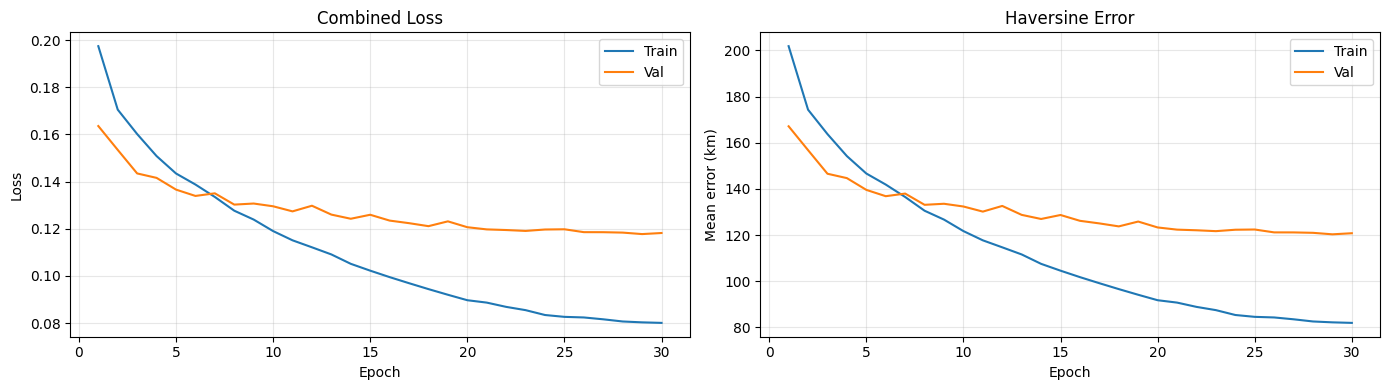

Saved: /content/drive/MyDrive/Vision_Project_2026/checkpoints_v6/training_curves.png


In [13]:
# Plot training curves
import matplotlib.pyplot as plt

if not history['train_loss']:
    print('No history yet.')
else:
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    ax1.plot(epochs, history['train_loss'], label='Train')
    ax1.plot(epochs, history['val_loss'],   label='Val')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title('Combined Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history['train_km'], label='Train')
    ax2.plot(epochs, history['val_km'],   label='Val')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Mean error (km)')
    ax2.set_title('Haversine Error'); ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    out = os.path.join(DRIVE_CHECKPOINT_DIR, 'training_curves.png')
    plt.savefig(out, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved: {out}")


In [14]:
# Diagnostics -- run after a few epochs to verify gradient flow
import torch

model.train()
imgs, targets = next(iter(train_loader))
imgs, targets = imgs.to(device), targets.to(device)

optimizer.zero_grad()
with torch.cuda.amp.autocast(enabled=USE_AMP):
    preds = model(imgs)
    loss  = combined_loss(preds, targets)
loss.backward()

print(f"LR          : {optimizer.param_groups[0]['lr']:.2e}")
print(f"Loss (batch): {loss.item():.5f}")

grad_norms = [(n, p.grad.norm().item())
              for n, p in model.named_parameters()
              if p.requires_grad and p.grad is not None]

if not grad_norms:
    print('No gradients -- model may be fully frozen.')
else:
    print(f"\nActive gradient layers: {len(grad_norms)}")
    for name, norm in sorted(grad_norms, key=lambda x: -x[1])[:12]:
        flag = '  <<< near-zero' if norm < 1e-7 else ''
        print(f"  {norm:.4e}  {name}{flag}")

model.eval()
with torch.no_grad():
    out = model(imgs)
print(f"\nOutput range: [{out.min():.4f}, {out.max():.4f}]  (expected 0-1)")
optimizer.zero_grad()


/tmp/ipykernel_694/3706825121.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


LR          : 1.00e-06
Loss (batch): 0.08927

Active gradient layers: 115
  9.6832e-01  geoclip.image_encoder.CLIP.vision_model.base_model.model.encoder.layers.21.self_attn.q_proj.lora_B.default.weight
  8.6931e-01  geoclip.image_encoder.CLIP.vision_model.base_model.model.encoder.layers.6.self_attn.v_proj.lora_A.default.weight
  8.3314e-01  geoclip.image_encoder.CLIP.vision_model.base_model.model.encoder.layers.6.self_attn.v_proj.lora_B.default.weight
  7.9612e-01  geoclip.image_encoder.CLIP.vision_model.base_model.model.encoder.layers.18.self_attn.v_proj.lora_B.default.weight
  7.1425e-01  geoclip.image_encoder.CLIP.vision_model.base_model.model.encoder.layers.17.self_attn.v_proj.lora_B.default.weight
  6.9903e-01  geoclip.image_encoder.CLIP.vision_model.base_model.model.encoder.layers.9.self_attn.v_proj.lora_B.default.weight
  6.9287e-01  geoclip.image_encoder.CLIP.vision_model.base_model.model.encoder.layers.8.self_attn.v_proj.lora_B.default.weight
  6.5926e-01  geoclip.image_encode

## Section 5 -- Evaluation

Runs on the held-out **val** and **test** sets. The test set is identical to `GeoClip_Evaluation.ipynb` (same seed and split ratio).

In [15]:
import numpy as np
import torch
from tqdm import tqdm


def denorm(n_lat, n_lon):
    return (n_lat * (MAX_LAT - MIN_LAT) + MIN_LAT,
            n_lon * (MAX_LON - MIN_LON) + MIN_LON)


def haversine_np(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1; dlon = lon2 - lon1
    a    = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 6371 * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def macro_region(lat):
    if lat > 44.0:   return 'Nord'
    elif lat > 41.5: return 'Centro'
    else:            return 'Sud/Isole'


def evaluate(model, loader, label):
    model.eval()
    preds_list, true_list = [], []
    with torch.no_grad():
        for imgs, targets in tqdm(loader, desc=label, leave=False):
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                out = model(imgs.to(device)).cpu().numpy()
            preds_list.append(out)
            true_list.append(targets.numpy())

    preds = np.vstack(preds_list)
    trues = np.vstack(true_list)
    p_lat, p_lon = denorm(preds[:, 0], preds[:, 1])
    t_lat, t_lon = denorm(trues[:, 0], trues[:, 1])
    errors       = haversine_np(p_lat, p_lon, t_lat, t_lon)

    print(f"\n{'='*55}")
    print(f"  {label}  ({len(errors):,} images)")
    print(f"{'='*55}")
    print(f"  Mean   : {np.mean(errors):.1f} km")
    print(f"  Median : {np.median(errors):.1f} km")
    print(f"  90th   : {np.percentile(errors, 90):.1f} km")
    for th in [25, 50, 100, 200, 500]:
        print(f"  Within {th:>4} km : {np.mean(errors <= th)*100:.1f}%")
    return errors, p_lat, p_lon, t_lat, t_lon


val_errors, vp_lat, vp_lon, vt_lat, vt_lon = evaluate(model, val_loader,  'Validation set')
tst_errors, tp_lat, tp_lon, tt_lat, tt_lon = evaluate(model, test_loader, 'Test set (held-out)')


Validation set:   0%|          | 0/261 [00:00<?, ?it/s]/tmp/ipykernel_694/737163036.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):



  Validation set  (4,168 images)
  Mean   : 120.5 km
  Median : 61.9 km
  90th   : 328.1 km
  Within   25 km : 28.0%
  Within   50 km : 43.8%
  Within  100 km : 63.0%
  Within  200 km : 79.8%
  Within  500 km : 96.8%



  Test set (held-out)  (4,904 images)
  Mean   : 122.2 km
  Median : 63.5 km
  90th   : 325.2 km
  Within   25 km : 27.8%
  Within   50 km : 43.8%
  Within  100 km : 61.7%
  Within  200 km : 79.5%
  Within  500 km : 96.6%


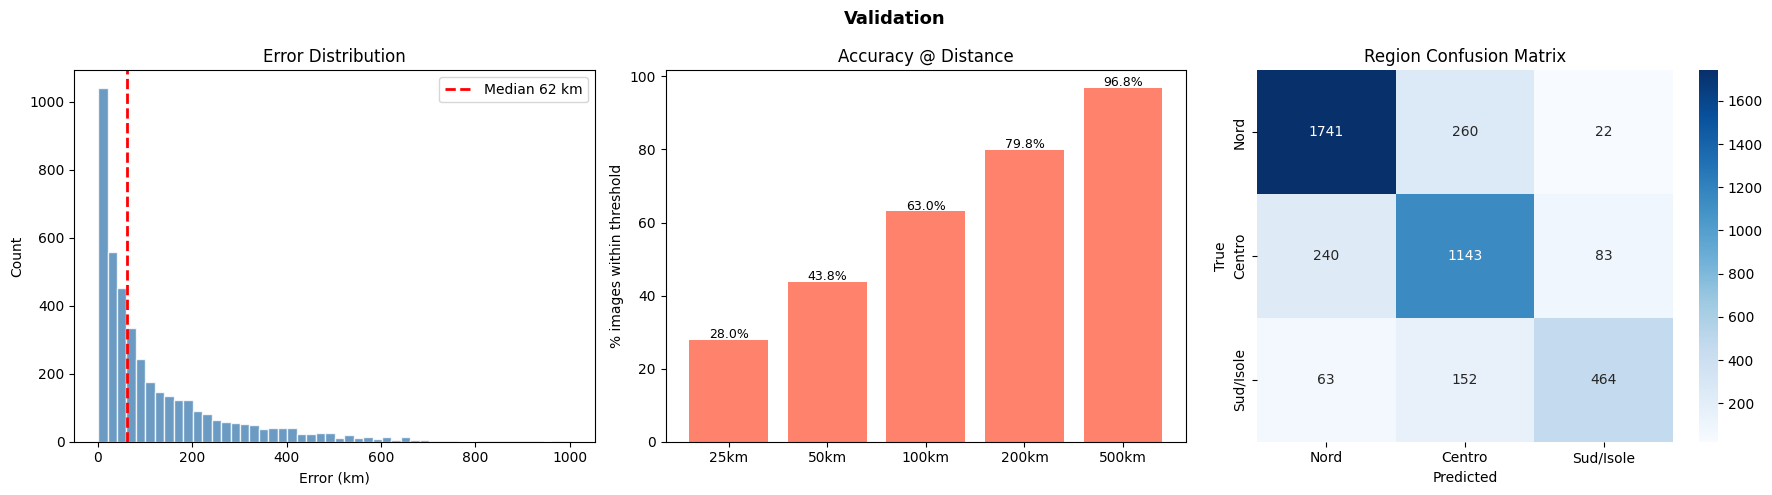

              precision    recall  f1-score   support

        Nord      0.852     0.861     0.856      2023
      Centro      0.735     0.780     0.757      1466
   Sud/Isole      0.815     0.683     0.744       679

    accuracy                          0.803      4168
   macro avg      0.801     0.775     0.785      4168
weighted avg      0.805     0.803     0.803      4168



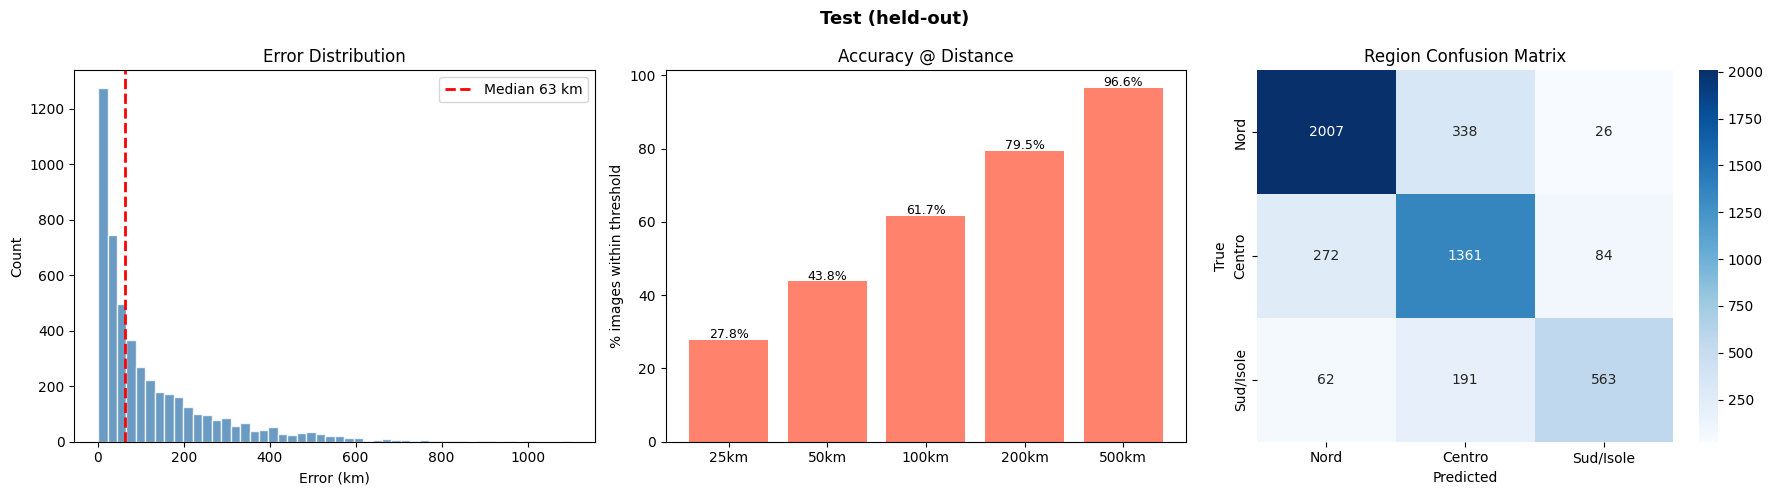

              precision    recall  f1-score   support

        Nord      0.857     0.846     0.852      2371
      Centro      0.720     0.793     0.755      1717
   Sud/Isole      0.837     0.690     0.756       816

    accuracy                          0.802      4904
   macro avg      0.805     0.776     0.788      4904
weighted avg      0.806     0.802     0.802      4904



In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix


def plot_eval(errors, p_lat, p_lon, t_lat, t_lon, title):
    labels = ['Nord', 'Centro', 'Sud/Isole']
    tr     = [macro_region(l) for l in t_lat]
    pr     = [macro_region(l) for l in p_lat]
    cm     = confusion_matrix(tr, pr, labels=labels)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    axes[0].hist(np.clip(errors, 0, 1200), bins=50, color='steelblue', alpha=0.8, edgecolor='white')
    axes[0].axvline(np.median(errors), color='red', lw=2, linestyle='--',
                    label=f'Median {np.median(errors):.0f} km')
    axes[0].set_xlabel('Error (km)'); axes[0].set_ylabel('Count')
    axes[0].set_title('Error Distribution'); axes[0].legend()

    ths  = [25, 50, 100, 200, 500]
    accs = [np.mean(errors <= t) * 100 for t in ths]
    bars = axes[1].bar([f'{t}km' for t in ths], accs, color='tomato', alpha=0.8)
    for bar, acc in zip(bars, accs):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{acc:.1f}%', ha='center', fontsize=9)
    axes[1].set_ylabel('% images within threshold')
    axes[1].set_title('Accuracy @ Distance')

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=axes[2])
    axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('True')
    axes[2].set_title('Region Confusion Matrix')

    plt.tight_layout()
    fname = os.path.join(DRIVE_CHECKPOINT_DIR, f"eval_{title.lower().replace(' ', '_')}.png")
    plt.savefig(fname, dpi=120, bbox_inches='tight')
    plt.show()
    print(classification_report(tr, pr, labels=labels, digits=3))


plot_eval(val_errors, vp_lat, vp_lon, vt_lat, vt_lon, 'Validation')
plot_eval(tst_errors, tp_lat, tp_lon, tt_lat, tt_lon, 'Test (held-out)')


In [17]:
# MC Dropout -- uncertainty estimation for a single image
# Set IMAGE_PATH and run.
import numpy as np
import os
import torch
from PIL import Image
from torchvision import transforms

IMAGE_PATH  = '/content/example.jpg'   # <-- change this
N_MC_PASSES = 50


def enable_dropout(m):
    for mod in m.modules():
        if mod.__class__.__name__.startswith('Dropout'):
            mod.train()


_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
                         std=[0.26862954, 0.26130258, 0.27577711]),
])


def mc_dropout_predict(model, img_path, n=50):
    img    = Image.open(img_path).convert('RGB')
    tensor = _tf(img).unsqueeze(0).to(device)
    model.eval()
    enable_dropout(model)
    preds = []
    with torch.no_grad():
        for _ in range(n):
            out = model(tensor).cpu().numpy()[0]
            lat = out[0] * (MAX_LAT - MIN_LAT) + MIN_LAT
            lon = out[1] * (MAX_LON - MIN_LON) + MIN_LON
            preds.append([lat, lon])
    model.eval()
    return np.array(preds)


if os.path.exists(IMAGE_PATH):
    preds = mc_dropout_predict(model, IMAGE_PATH, n=N_MC_PASSES)
    print(f"Mean: lat={preds[:,0].mean():.4f}  lon={preds[:,1].mean():.4f}")
    print(f"Std : lat={preds[:,0].std():.4f}  lon={preds[:,1].std():.4f}")

    try:
        import folium
        from folium.plugins import HeatMap
        from IPython.display import display

        m = folium.Map(location=[preds[:,0].mean(), preds[:,1].mean()], zoom_start=7,
                       tiles='CartoDB dark_matter')
        HeatMap(preds.tolist(), radius=25, blur=15).add_to(m)
        folium.Marker([preds[:,0].mean(), preds[:,1].mean()],
                      popup='Mean prediction',
                      icon=folium.Icon(color='orange', icon='star')).add_to(m)
        display(m)
    except ImportError:
        print('folium not installed -- skipping map.')
else:
    print(f"Set IMAGE_PATH to an existing file. '{IMAGE_PATH}' not found.")


Set IMAGE_PATH to an existing file. '/content/example.jpg' not found.
